# Feature Engineeering

**Handling Missing Values**

In [2]:
import seaborn as sns

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
# Check Missing
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

**Minimus Missing Values found in**

- embarked
- embark_down

We can simply drop it

# Handling Missing value Technique

```bash
1. Simple Elimination
2. Statistical Imputation (Mean/Median/Mode)
3. Multivariate Imputation (Iterative Imputer)
4. KNN Imputer

# 📘 1. Simple Elimination

```bash
Theory: The "Delete" strategy. You remove any row (observation) or column (feature) that contains a missing value.
The "When": Only use this if the missing data is "Missing Completely at Random" (MCAR) and represents less than 5% of your total data.
The Warning: Deleting data is like throwing away puzzle pieces. If you delete too many, you can't see the full picture.

Example Code:

```bash
# Drop rows with any missing values
df_cleaned = df.dropna()

# Drop a column if it has more than 50% missing values
df_cleaned = df.drop(columns=['column_with_too_many_nans'])


In [7]:
# Drop Missing values with minimum missing values

df_cleaned = df.dropna(subset=['embarked','embark_town'])
df_cleaned.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

# 📊 2. Statistical Imputation (Univariate) - Mean/Median/ Mode

```bash
Theory: Filling holes with a single calculated value from that column.
Mean: Good for normal distributions.
Median: Best for skewed data (salaries, house prices) because it ignores outliers.
Mode: The only option for categorical data (e.g., filling "City" with the most frequent city).

```bash
Example Code :
from sklearn.impute import SimpleImputer

# Fill with Median
imputer = SimpleImputer(strategy='median')
df['Age'] = imputer.fit_transform(df[['Age']])

🔍 Step 1: Check for outliers

In [8]:
df_cleaned.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
Q1 = df['age'].quantile(.25)
Q3 = df['age'].quantile(.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
outliers # These are acually outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
456,0,1,male,65.0,0,0,26.5500,S,First,man,True,E,Southampton,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False


📊 Optional: Visual check (recommended)

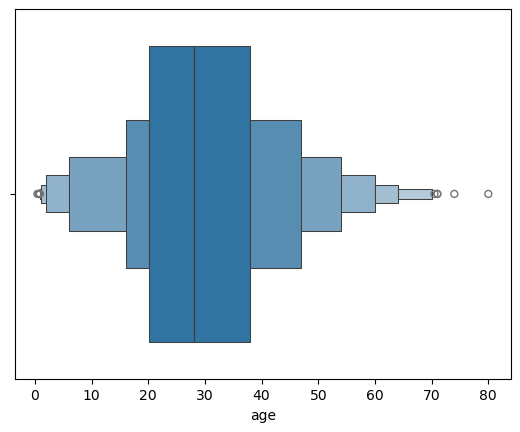

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxenplot(x=df['age'])
plt.show()

In [11]:
# Simple Imputer
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')

df['age'] = num_imputer.fit_transform(df[['age']])
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# 🤖 3. Advanced: Multivariate Imputation (Iterative Imputer)

```bash

Theory: Instead of looking at one column, we use the other columns to predict the missing value.
Iterative Imputer: It treats the missing column as a `target and uses other features to run a regression to guess the value.
KNN Imputer: It finds the `K` "closest" rows to the one with the missing value and averages their numbers.

Rather than just guessing the median age, we can use other features like pclass (class) and fare to predict the missing age.

In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

it_imputer = IterativeImputer(random_state=42)
# Use relevant numerical columns to estimate the age

df[['age','pclass','fare']] = it_imputer.fit_transform(df[['age','pclass','fare']])
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

```bash
This code is using Iterative Imputer (a multivariate imputation method) from scikit-learn to fill in missing values—especially for the age column—based on relationships with other columns.

* IterativeImputer is still marked experimental, so you must explicitly enable it.
* It performs model-based imputation, unlike simple methods like mean/median.

* random_state=42 ensures reproducibility.


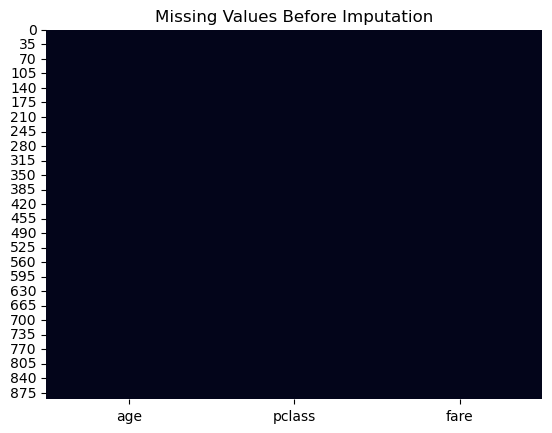

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['age','pclass','fare']].isnull(), cbar=False)
plt.title("Missing Values Before Imputation")
plt.show()

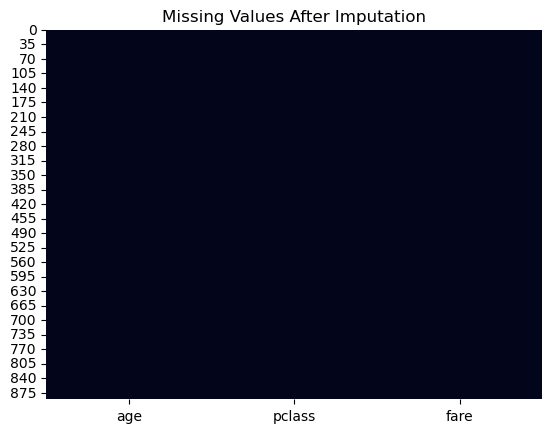

In [15]:
sns.heatmap(df[['age','pclass','fare']].isnull(), cbar=False)
plt.title("Missing Values After Imputation")
plt.show()

# 4. KNN Imputation

KNNImputer is much easier to understand than IterativeImputer if you think in terms of “similar rows help each other.”

```bash

```bash
Example:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)
df_filled = knn.fit_transform(df_numeric)

In [17]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [19]:
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

df['age'] = knn_imputer.fit_transform(df[['age']])
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64